In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [4]:
import zipfile
import os

zip_path = 'archive (4).zip'
extract_path = '/content/data/'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting")

Done extracting


In [5]:
import os
os.listdir('/content/data/')

['DAYTON_hourly.csv',
 'DEOK_hourly.csv',
 'PJME_hourly.csv',
 'AEP_hourly.csv',
 'pjm_hourly_est.csv',
 'EKPC_hourly.csv',
 'FE_hourly.csv',
 'est_hourly.paruqet',
 'DUQ_hourly.csv',
 'DOM_hourly.csv',
 'COMED_hourly.csv',
 'NI_hourly.csv',
 'PJM_Load_hourly.csv',
 'PJMW_hourly.csv']

In [7]:
import pandas as pd

df = pd.read_csv('/content/data/PJME_hourly.csv')
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [8]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

df.rename(columns={'PJME_MW': 'consumption'}, inplace=True)

df.head()

,consumption
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [9]:
# Time features
df['hour'] = df.index.hour
df['day'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day'].apply(lambda x: 1 if x >= 5 else 0)

# Lag features
df['lag_1'] = df['consumption'].shift(1)
df['lag_24'] = df['consumption'].shift(24)

# Rolling mean
df['rolling_mean_24'] = df['consumption'].rolling(24).mean()

df.dropna(inplace=True)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop('consumption', axis=1)
y = df['consumption']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 788.4191636202979
R2 Score: 0.9854174367215318


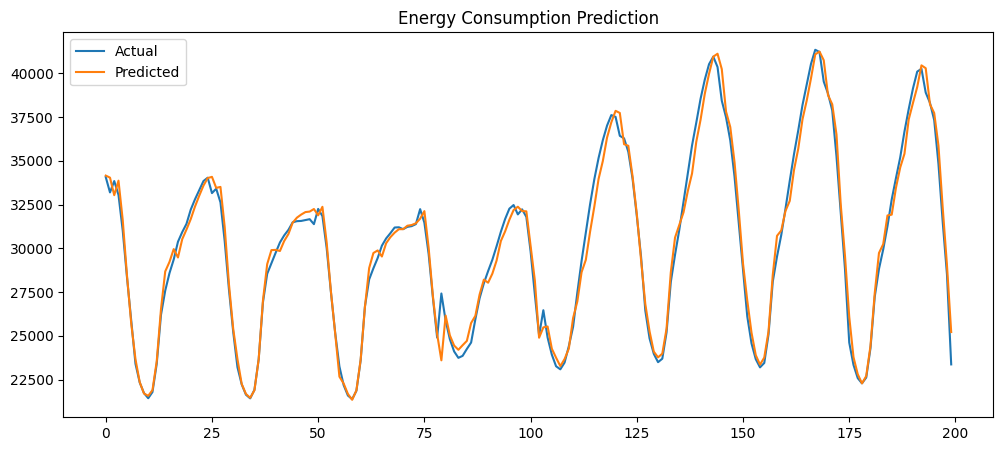

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("Energy Consumption Prediction")
plt.show()

In [19]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))

In [20]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>